In [1]:
library(ggplot2)
library(data.table)
theme_set(theme_bw())

In [2]:
tools = c('singlem', 'sylph', 'singlem_joint_a846591', 'singlem-regime3')
publication_names = data.table(
    tool = tools,
    publication_name = c('SingleM', 'sylph', 'SingleM joint', 'SingleM regime3')
)
communities = paste0('strain',as.character(0:99))
d1 = data.table(expand.grid(tool = tools, community = communities))
# output_singlem/opal/GCA_022615805.1_genomic.opal_report
readit = function(tool, community){
    to_read = paste('output_',tool,sep='','/opal/',community,'.opal_report')
    # print(to_read)
    return(fread(to_read))
}
d2 = publication_names[d1[, readit(tool, community), by=list(tool,community)], on = "tool"]
d2[1:3]

tool,publication_name,community,i.tool,rank,metric,sample,value
<chr>,<chr>,<fct>,<chr>,<chr>,<chr>,<chr>,<dbl>
singlem,SingleM,strain0,Gold standard,kingdom,Bray-Curtis distance,SAMPLEID,0
singlem,SingleM,strain0,Gold standard,phylum,Bray-Curtis distance,SAMPLEID,0
singlem,SingleM,strain0,Gold standard,class,Bray-Curtis distance,SAMPLEID,0


In [3]:
setnames(d2, c('tool','publication_name', 'community', 'blah','rank','metric','sample','value'))
d3 = d2[blah != 'Gold standard'][,.(tool, publication_name, community, rank, metric, value)]
d3[, rank := factor(rank, c('kingdom','phylum','class','order','family','genus','species'))]

In [4]:
fwrite(d3, 'accuracy_results.csv')# write out bc
fwrite(d3[metric == "Bray-curtis distance"], 'bray-curtis.csv', sep='\t')

In [5]:
s1 = dcast(d3, ...~metric, value.var='value')
s1[, c("tool", "publication_name") := list(publication_name, NULL)]

s1 = s1[order(rank, tool)]
fwrite(s1, 'opal_summary.csv', sep='\t')

Warning message:
“Removed 300 rows containing missing values or values outside the scale range
(`stat_boxplot()`).”


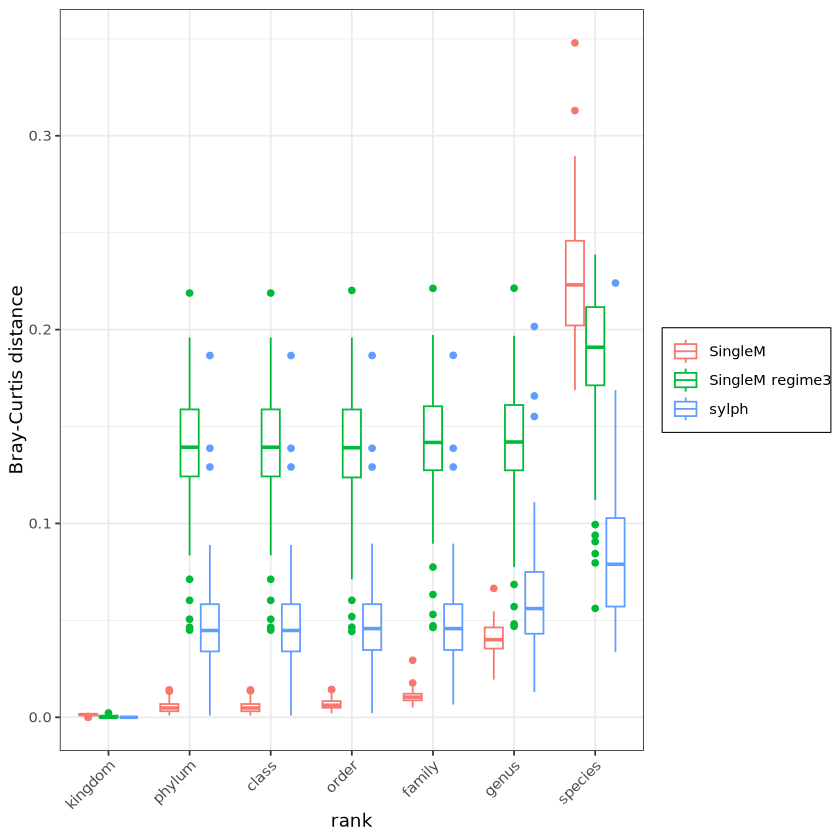

In [9]:
# Remove figure legend title, and put the legend in bottom left of plot, with a bounding box
plot_metric <- function(data, metric) {
   ggplot(data, aes(rank, {{metric}}, colour = tool)) +
      geom_boxplot() +
      scale_x_discrete(na.translate = FALSE) +
      theme(axis.text.x = element_text(angle = 45, hjust = 1)) +
      theme(legend.title=element_blank()) +
      #theme(legend.position=c(0.1,0.4)) +
      theme(legend.background = element_rect(colour = "black", linewidth = 0.3))
}
plot_metric(s1[tool != "SingleM joint"], `Bray-Curtis distance`)

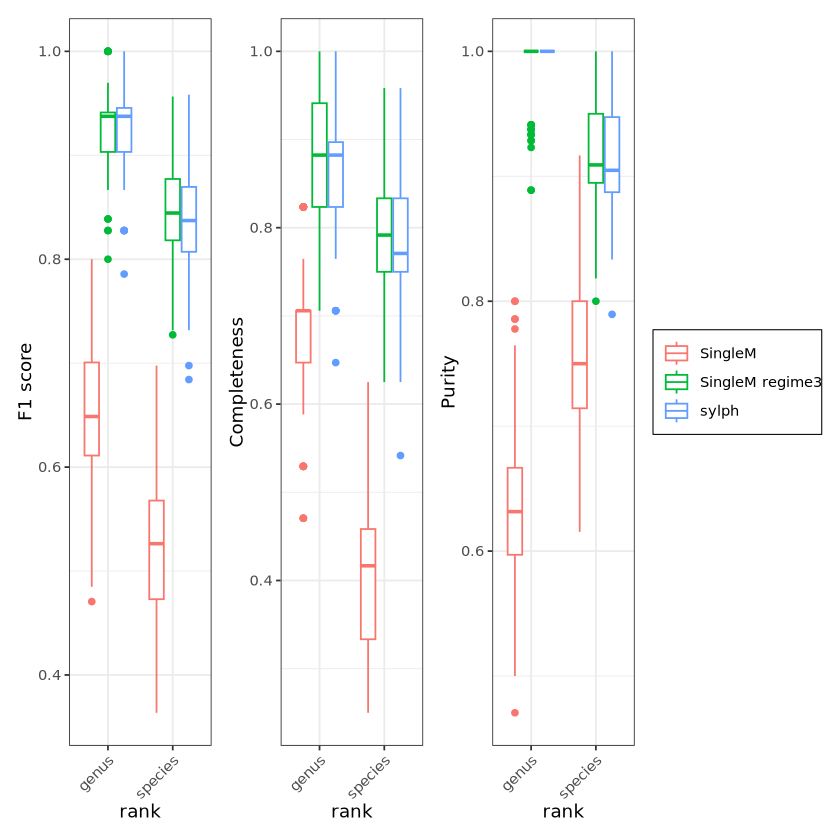

In [7]:
lapply(c('F1 score', 'Completeness', 'Purity'),
       \(m) plot_metric(s1[rank %in% c('species', 'genus') & tool != 'SingleM joint'], .data[[m]])) |>
    patchwork::wrap_plots(guides = 'collect')

Warning message:
“Removed 2100 rows containing non-finite outside the scale range
(`stat_boxplot()`).”


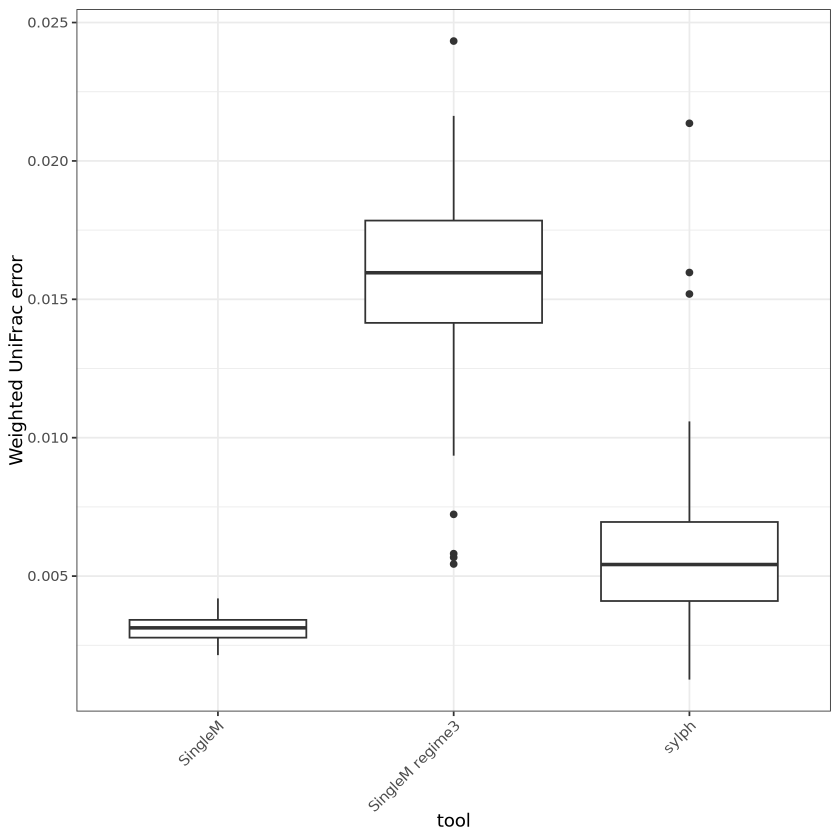

In [8]:

ggplot(s1[tool != 'SingleM joint'], aes(tool, `Weighted UniFrac error`)) +
    geom_boxplot() +
    scale_x_discrete(na.translate = FALSE) +
    theme(axis.text.x = element_text(angle = 45, hjust = 1)) +
    theme(legend.title=element_blank()) +
    theme(legend.position=c(0.1,0.4)) +
    theme(legend.background = element_rect(colour = "black", linewidth = 0.3))